In [6]:
# Instalación (si es necesario) y carga de librerías
#if(!require(mlbench)) install.packages("mlbench")
#if(!require(tidyverse)) install.packages("tidyverse")
#if(!require(corrplot)) install.packages("corrplot")

library(mlbench)
library(dplyr)
library(corrplot)
library(ggplot2)

# Carga del dataset desde el archivo local 'data/breast_cancer_data.csv'
df <- read.csv('../data/breast_cancer_data.csv', sep = ',', stringsAsFactors = FALSE)

cat("Dataset cargado exitosamente.\n")

#------------------------------------------------------------
# Etapa 2: Inspección Inicial y Estructura
#------------------------------------------------------------
# Visualización de las primeras filas
head(df)


Dataset cargado exitosamente.


,mean.radius,mean.texture,mean.perimeter,mean.area,mean.smoothness,mean.compactness,mean.concavity,mean.concave.points,mean.symmetry,mean.fractal.dimension,⋯,worst.texture,worst.perimeter,worst.area,worst.smoothness,worst.compactness,worst.concavity,worst.concave.points,worst.symmetry,worst.fractal.dimension,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,⋯,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,⋯,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,⋯,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,⋯,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,⋯,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
6,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,⋯,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0


'data.frame':	569 obs. of  31 variables:
 $ mean.radius            : num  18 20.6 19.7 11.4 20.3 ...
 $ mean.texture           : num  10.4 17.8 21.2 20.4 14.3 ...
 $ mean.perimeter         : num  122.8 132.9 130 77.6 135.1 ...
 $ mean.area              : num  1001 1326 1203 386 1297 ...
 $ mean.smoothness        : num  0.1184 0.0847 0.1096 0.1425 0.1003 ...
 $ mean.compactness       : num  0.2776 0.0786 0.1599 0.2839 0.1328 ...
 $ mean.concavity         : num  0.3001 0.0869 0.1974 0.2414 0.198 ...
 $ mean.concave.points    : num  0.1471 0.0702 0.1279 0.1052 0.1043 ...
 $ mean.symmetry          : num  0.242 0.181 0.207 0.26 0.181 ...
 $ mean.fractal.dimension : num  0.0787 0.0567 0.06 0.0974 0.0588 ...
 $ radius.error           : num  1.095 0.543 0.746 0.496 0.757 ...
 $ texture.error          : num  0.905 0.734 0.787 1.156 0.781 ...
 $ perimeter.error        : num  8.59 3.4 4.58 3.44 5.44 ...
 $ area.error             : num  153.4 74.1 94 27.2 94.4 ...
 $ smoothness.error       : num  

  mean.radius      mean.texture   mean.perimeter     mean.area     
 Min.   : 6.981   Min.   : 9.71   Min.   : 43.79   Min.   : 143.5  
 1st Qu.:11.700   1st Qu.:16.17   1st Qu.: 75.17   1st Qu.: 420.3  
 Median :13.370   Median :18.84   Median : 86.24   Median : 551.1  
 Mean   :14.127   Mean   :19.29   Mean   : 91.97   Mean   : 654.9  
 3rd Qu.:15.780   3rd Qu.:21.80   3rd Qu.:104.10   3rd Qu.: 782.7  
 Max.   :28.110   Max.   :39.28   Max.   :188.50   Max.   :2501.0  
 mean.smoothness   mean.compactness  mean.concavity    mean.concave.points
 Min.   :0.05263   Min.   :0.01938   Min.   :0.00000   Min.   :0.00000    
 1st Qu.:0.08637   1st Qu.:0.06492   1st Qu.:0.02956   1st Qu.:0.02031    
 Median :0.09587   Median :0.09263   Median :0.06154   Median :0.03350    
 Mean   :0.09636   Mean   :0.10434   Mean   :0.08880   Mean   :0.04892    
 3rd Qu.:0.10530   3rd Qu.:0.13040   3rd Qu.:0.13070   3rd Qu.:0.07400    
 Max.   :0.16340   Max.   :0.34540   Max.   :0.42680   Max.   :0.20120    

mean.radius            mean.texture          mean.perimeter 
                      0                       0                       0 
              mean.area         mean.smoothness        mean.compactness 
                      0                       0                       0 
         mean.concavity     mean.concave.points           mean.symmetry 
                      0                       0                       0 
 mean.fractal.dimension            radius.error           texture.error 
                      0                       0                       0 
        perimeter.error              area.error        smoothness.error 
                      0                       0                       0 
      compactness.error         concavity.error    concave.points.error 
                      0                       0                       0 
         symmetry.error fractal.dimension.error            worst.radius 
                      0                       0                       0 
          worst.texture         worst.perimeter              worst.area 
                      0                       0                       0 
       worst.smoothness       worst.compactness         worst.concavity 
                      0                       0                       0 
   worst.concave.points          worst.symmetry worst.fractal.dimension 
                      0                       0                       0 
                 target 
                      0

Warning message:
“The following aesthetics were dropped during statistical transformation: fill.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


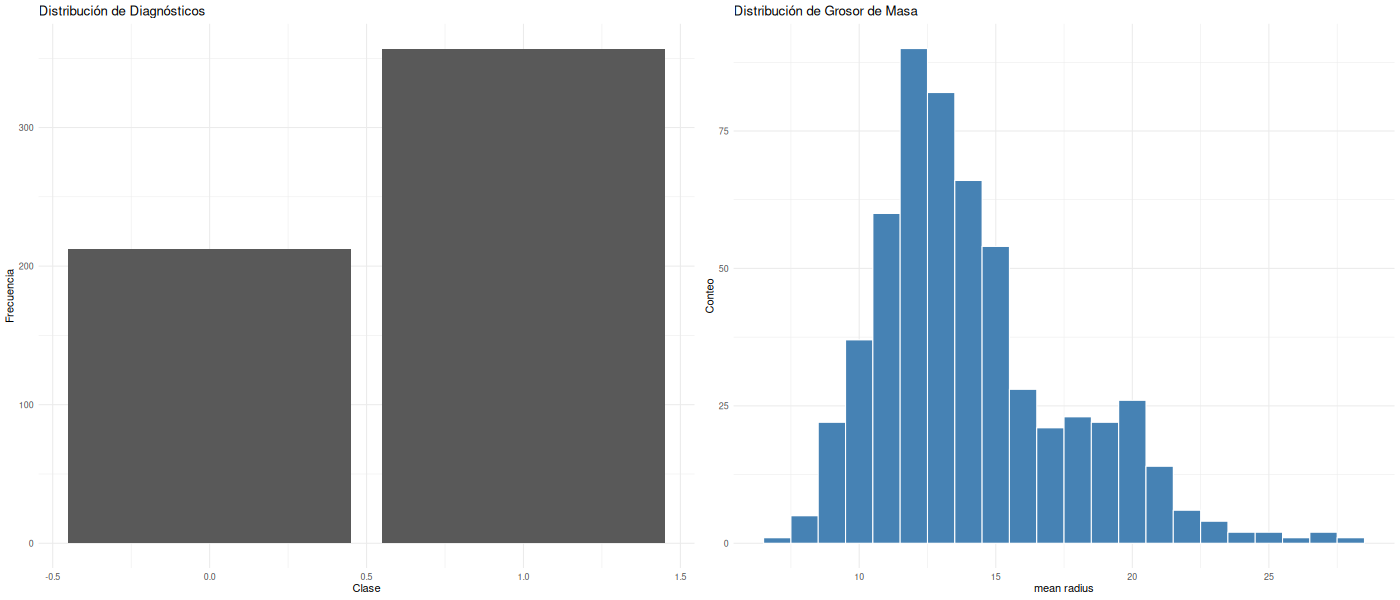

In [ ]:

# Estructura del dataset (tipos de datos)
str(df)

# Resumen estadístico descriptivo
summary(df)


#------------------------------------------------------------
#Etapa 3: Limpieza de Datos
#------------------------------------------------------------
# Conversión de columnas de factores a numéricas (excepto la variable objetivo 'Class')
df_numeric <- df
df_numeric[,-10] <- sapply(df_numeric[,-10], function(x) as.numeric(as.character(x)))

# Verificación de valores faltantes (NA)
colSums(is.na(df_numeric))

# Eliminamos filas con NAs para este ejemplo
df_clean <- na.omit(df_numeric)


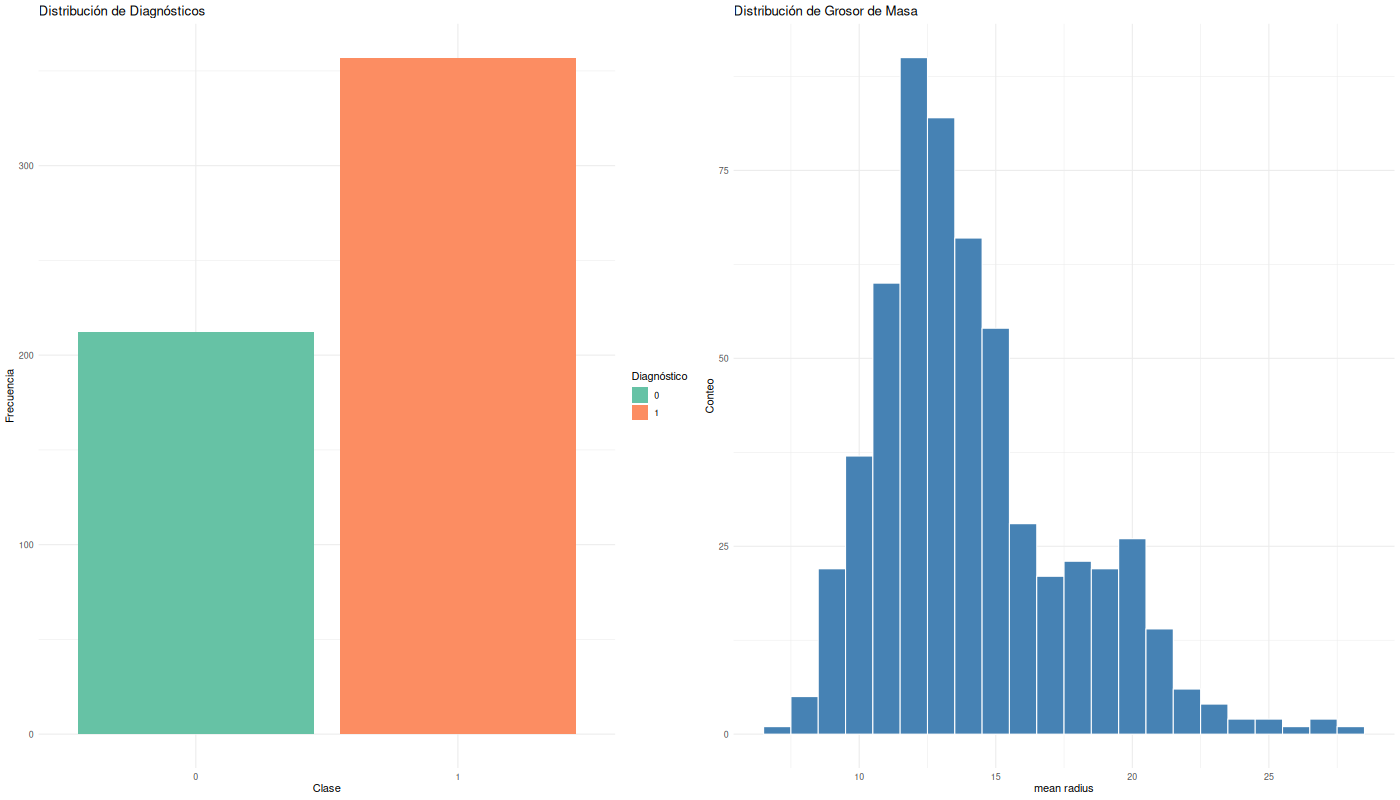

In [26]:

#------------------------------------------------------------
# Etapa 4: Análisis Univariado (Distribuciones)
#------------------------------------------------------------
# Ajuste de tamaño para Jupyter: 700 px por gráfico (2 gráficos en una fila = 1400 px total)
options(repr.plot.width = 1400 / 72, repr.plot.height = 800 / 72, repr.plot.res = 72)

# Distribución de la variable objetivo
p1 <- ggplot(df_clean, aes(x = as.factor(target), fill = as.factor(target))) +
  geom_bar() +
  scale_fill_brewer(palette = "Set2", name = "Diagnóstico") +
  theme_minimal() +
  labs(title = "Distribución de Diagnósticos", x = "Clase", y = "Frecuencia")

# Histograma de una característica (ej. Clump Thickness)
p2 <- ggplot(df_clean, aes(x = mean.radius)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  theme_minimal() +
  labs(title = "Distribución de Grosor de Masa", x = "mean radius", y = "Conteo")

# Mostrar ambos gráficos en 1 fila y 2 columnas
gridExtra::grid.arrange(p1, p2, ncol = 2)


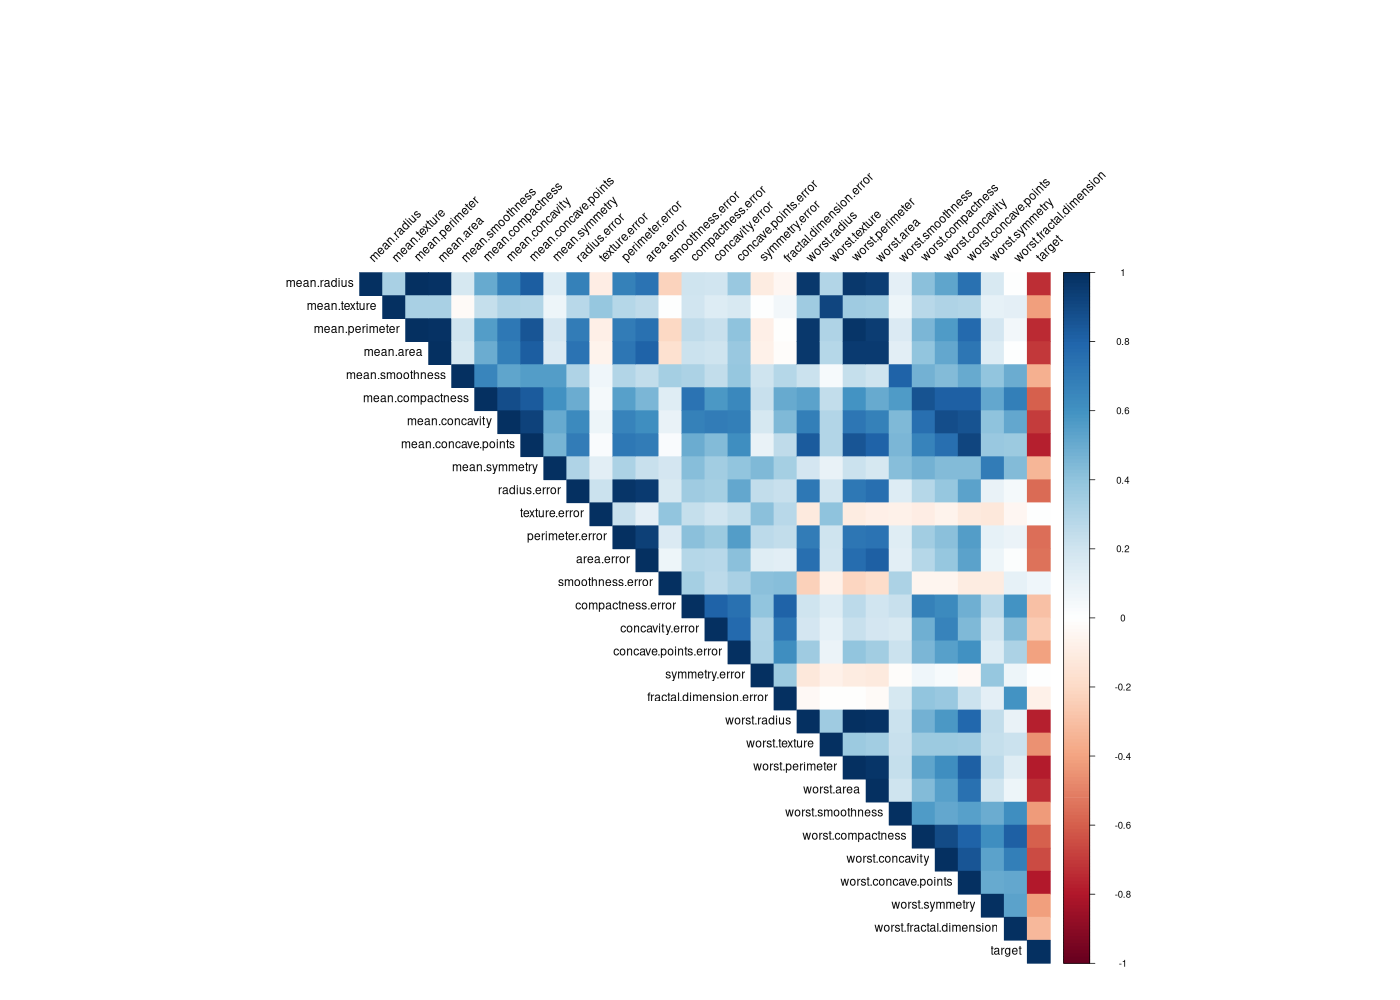

In [28]:

options(repr.plot.width = 1400 / 72, repr.plot.height = 1000 / 72, repr.plot.res = 72)
#------------------------------------------------------------
# Etapa 5: Análisis Bivariado y Correlaciones
#------------------------------------------------------------
# Matriz de correlación de df_clean (excluyendo la columna target)
cor_matrix <- cor(df_clean[,-10]) # Excluimos la variable objetivo 'target'


# Visualización del Mapa de Calor
corrplot(
  cor_matrix,
  method = "color",
  type = "upper",
  tl.col = "black",
  tl.srt = 45
)


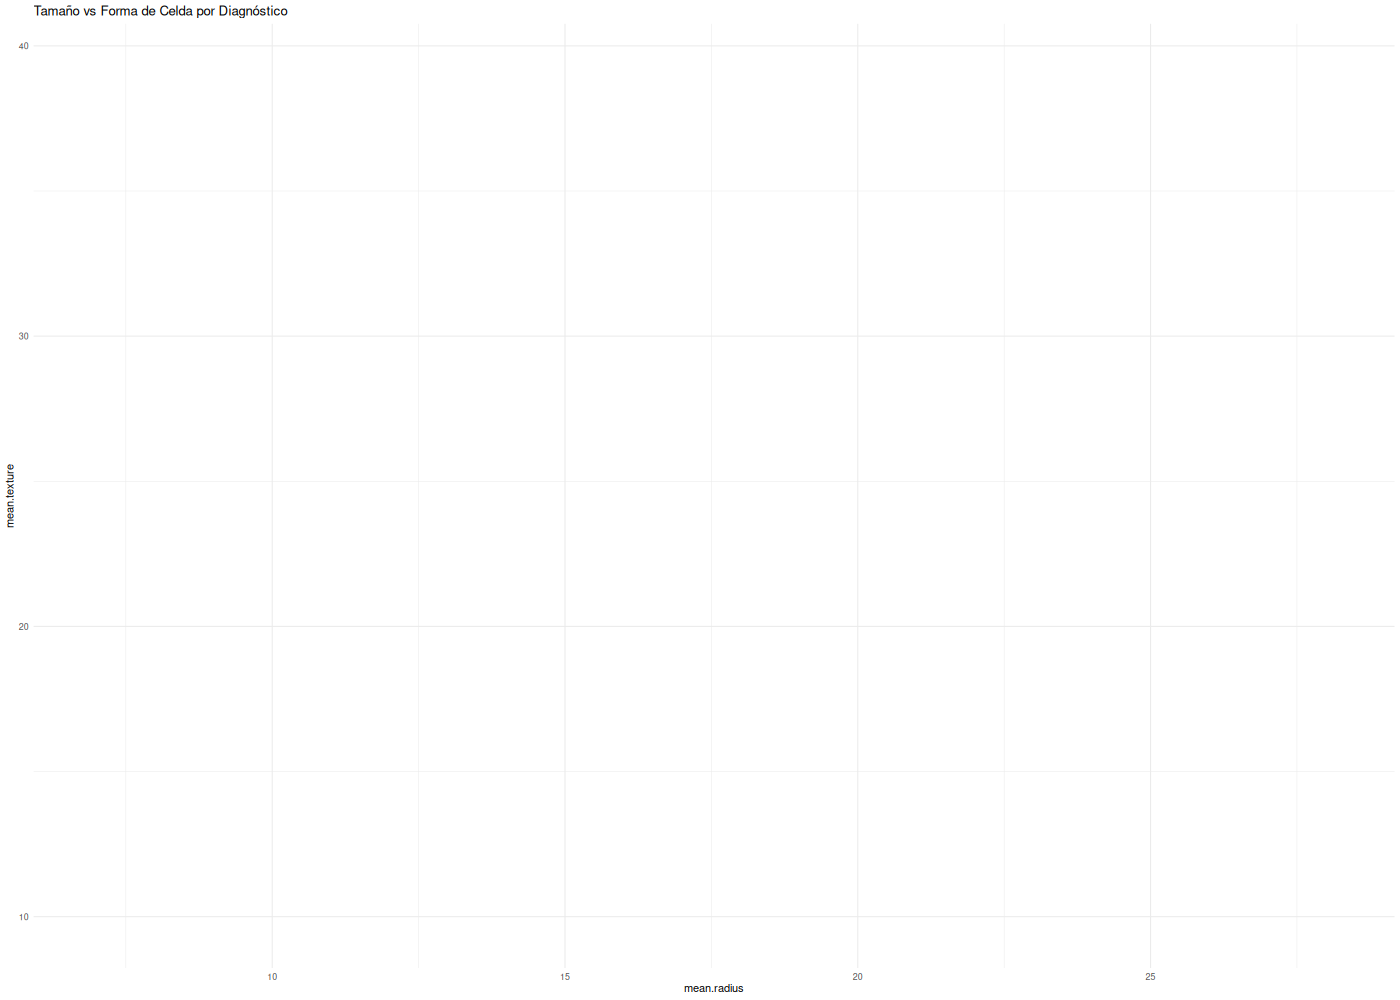

In [ ]:

# Relación entre Cel.size y Cel.shape coloreado por Clase
ggplot(df_clean, aes(x = mean.radius, y = mean.texture, color = target)) +
  theme_minimal() +
  labs(title = "Radio Medio vs Textura Media por Diagnóstico")


In [ ]:

#------------------------------------------------------------
# Etapa 6: Identificación de Valores Atípicos (Outliers)
#------------------------------------------------------------
# Transformamos los datos a formato largo para graficar múltiples boxplots
df_long <- df_clean %>%
  pivot_longer(cols = -Class, names_to = "Caracteristica", values_to = "Valor")

# Gráfico de Boxplots
ggplot(df_long, aes(x = Caracteristica, y = Valor, fill = Caracteristica)) +
  geom_boxplot() +
  coord_flip() + # Giramos para mejor lectura
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "Detección de Outliers en Características", x = "", y = "Valor (Escala 1-10)")